In [1]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel,AutoModelForCausalLM
from sklearn.mixture import GaussianMixture
def load_model_and_tokenizer(model_name, device, torch_dtype=torch.float16):
    """prepare LLM and tokenizer"""

    model = AutoModelForCausalLM.from_pretrained(model_name, attn_implementation="eager", torch_dtype=torch_dtype, low_cpu_mem_usage=True).to(device)

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    tokenizer.pad_token = tokenizer.eos_token
    model.config.pad_token_id = model.config.eos_token_id
    
    return model, tokenizer
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model,tokenizer=load_model_and_tokenizer("google/gemma-2-9b-it",device)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [2]:

# Example Datasets (same as before)
factual_prompts = [
    "What is the capital of France?",
    "Who wrote the play Hamlet?",
    "What is the chemical formula for water?",
    "Define the theory of relativity.",
    "Explain the process of photosynthesis.",
    "What year did the Titanic sink?",
    "Who was the first person to walk on the moon?",
    "What is the boiling point of water in Celsius?",
    "Describe the function of the mitochondria.",
    "Who painted the Mona Lisa?",
]

test_prompts = [
    "What is the largest planet in our solar system?", # Factual
    "Who is the prime minister of Japan?", # Factual
    "Tell me about the key events of World War II.", # Borderline
    "Write a short story about a futuristic city.", # Creative
    "Invent a new type of pasta and describe it.", # Creative
    "What if dinosaurs never went extinct?", # Creative
    "Compose a lullaby for a baby robot.", # Creative
]


In [10]:
def get_chat(model_name: str, question: str):
    """Creates the chat structure for different LLMs."""
    # This is a simplified version of your prompt formatting.
    # In your real code, you might have more complex logic in INSTRUCT.
    prompt = f"Answer the question concisely. Q: {question} A:"
    
    # Based on your get_chat function for Gemma
    chat = [
        {"role": "user", "content": prompt},
    ]
    return chat

In [8]:
def get_prompt_embedding_formatted(prompt_text: str, tokenizer, model, model_name: str = "gemma"):
    """
    Computes the hidden state for a prompt AFTER applying the chat template.
    This is the CORRECT way to get a meaningful prompt embedding for classification.
    """
    # 1. Create the chat dictionary structure
    chat = get_chat(model_name, prompt_text)
    
    # 2. Apply the model-specific chat template
    # This adds special tokens like <start_of_turn>user...
    formatted_prompt = tokenizer.apply_chat_template(
        chat, 
        tokenize=False, 
        add_generation_prompt=True
    )
    
    # 3. Tokenize the fully formatted prompt
    inputs = tokenizer(formatted_prompt, return_tensors="pt").to(model.device)

    # 4. Get the hidden states from the model
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    
    # 5. Extract the embedding of the LAST token
    hidden_states = outputs.hidden_states[-1]
    embedding = hidden_states[0, -1, :]
    
    return embedding

In [7]:
def get_prompt_embedding(prompt: str, tokenizer, model):
    """
    Computes the hidden state for a prompt using a Causal LM.
    We use the embedding of the LAST token as the prompt's representation.
    """
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, padding=True).to(model.device)
    with torch.no_grad():
        # Set output_hidden_states=True to access all layer states
        outputs = model(**inputs, output_hidden_states=True)
    
    # Get the last hidden state from the model's output tuple
    # Shape: (batch_size, sequence_length, hidden_dim)
    hidden_states = outputs.hidden_states[-1]
    
    # Get the embedding of the last token
    # Shape: (hidden_dim,)
    embedding = hidden_states[0, -1, :].cpu().numpy()
    return embedding

In [44]:
class GeometricSoftGating:
    def __init__(self, factual_prompts: list, tokenizer, model, k: float = 2.0):
        self.tokenizer = tokenizer
        self.model = model
        self.k = k
        print("\n--- Method 1: Setting up Geometric Soft Gating ---")
        self._setup(factual_prompts)

    def _setup(self, prompts: list):
        print("  Calculating embeddings for factual prompts...")
        embeddings = np.array([get_prompt_embedding_formatted(p, self.tokenizer, self.model) for p in prompts])
        self.centroid = np.mean(embeddings, axis=0)
        centroid_norm = np.linalg.norm(self.centroid)
        embeddings_norm = np.linalg.norm(embeddings, axis=1)
        similarities = np.dot(embeddings, self.centroid) / (embeddings_norm * centroid_norm)
        self.s_avg = np.mean(similarities)
        self.s_std = np.std(similarities)
        print(f"  Pre-computation complete.")
        print(f"    - Factual Centroid Shape: {self.centroid.shape}")
        print(f"    - Average Similarity (s_avg): {self.s_avg:.4f}")
        print(f"    - Similarity Std Dev (s_std): {self.s_std:.4f}")

    def get_gate_value(self, prompt: str) -> float:
        h_new = get_prompt_embedding_formatted(prompt, self.tokenizer, self.model)
        s_new = np.dot(h_new, self.centroid) / (np.linalg.norm(h_new) * np.linalg.norm(self.centroid))
        normalized_s = (s_new - self.s_avg) / (self.s_std + 1e-8)
        gate_value = 1 / (1 + np.exp(-self.k * normalized_s))
        return gate_value

In [45]:
geometric_gate = GeometricSoftGating(factual_prompts, tokenizer, model)
print("\n--- [RESULTS] Method 1: Geometric Soft Gating ---")
for prompt in test_prompts:
    score = geometric_gate.get_gate_value(prompt)
    print(f"Score: {score:.4f}\tPrompt: {prompt}")



--- Method 1: Setting up Geometric Soft Gating ---
  Calculating embeddings for factual prompts...
  Pre-computation complete.
    - Factual Centroid Shape: (3584,)
    - Average Similarity (s_avg): 0.6616
    - Similarity Std Dev (s_std): 0.0739

--- [RESULTS] Method 1: Geometric Soft Gating ---
Score: 0.4214	Prompt: What is the largest planet in our solar system?
Score: 0.0750	Prompt: Who is the prime minister of Japan?
Score: 0.3059	Prompt: Tell me about the key events of World War II.
Score: 0.0151	Prompt: Write a short story about a futuristic city.
Score: 0.0311	Prompt: Invent a new type of pasta and describe it.
Score: 0.1893	Prompt: What if dinosaurs never went extinct?
Score: 0.0033	Prompt: Compose a lullaby for a baby robot.


In [49]:
geometric_gate.k=2
print("\n--- [RESULTS] Method 1: Geometric Soft Gating ---")
for prompt in test_prompts:
    score = geometric_gate.get_gate_value(prompt)
    print(f"Score: {score:.4f}\tPrompt: {prompt}")


--- [RESULTS] Method 1: Geometric Soft Gating ---
Score: 0.4214	Prompt: What is the largest planet in our solar system?
Score: 0.0750	Prompt: Who is the prime minister of Japan?
Score: 0.3059	Prompt: Tell me about the key events of World War II.
Score: 0.0151	Prompt: Write a short story about a futuristic city.
Score: 0.0311	Prompt: Invent a new type of pasta and describe it.
Score: 0.1893	Prompt: What if dinosaurs never went extinct?
Score: 0.0033	Prompt: Compose a lullaby for a baby robot.


2.0

In [3]:
from datasets import load_dataset

In [4]:
ds = load_dataset("truthfulqa/truthful_qa", "generation", split="validation")

In [5]:
factual_prompts=[prompt for prompt in ds["question"]]

In [28]:
geometric_gate = GeometricSoftGating(factual_prompts, tokenizer, model)
print("\n--- [RESULTS] Method 1: Geometric Soft Gating ---")
for prompt in test_prompts:
    score = geometric_gate.get_gate_value(prompt)
    print(f"Score: {score:.4f}\tPrompt: {prompt}")


--- Method 1: Setting up Geometric Soft Gating ---
  Calculating embeddings for factual prompts...
  Pre-computation complete.
    - Factual Centroid Shape: (3584,)
    - Average Similarity (s_avg): 0.6616
    - Similarity Std Dev (s_std): 0.0739

--- [RESULTS] Method 1: Geometric Soft Gating ---
Score: 0.0000	Prompt: What is the largest planet in our solar system?
Score: 0.0000	Prompt: Who is the prime minister of Japan?


/tmp/ipykernel_848322/4825474.py:27: RuntimeWarning: overflow encountered in exp
  gate_value = 1 / (1 + np.exp(-self.k * normalized_s))


Score: 0.0000	Prompt: Tell me about the key events of World War II.
Score: 0.0000	Prompt: Write a short story about a futuristic city.
Score: 0.0000	Prompt: Invent a new type of pasta and describe it.
Score: 0.0000	Prompt: What if dinosaurs never went extinct?
Score: 0.0000	Prompt: Compose a lullaby for a baby robot.


In [50]:
class ProbabilisticSoftGating:
    """
    Calculates a continuous [0, 1] gate value based on the likelihood
    of a prompt under a Gaussian model fitted on factual data.
    """
    def __init__(self, factual_prompts: list, tokenizer, model, k: float = 1.0):
        """
        Initializes and fits the Gaussian model.
        """
        self.tokenizer = tokenizer
        self.model = model
        self.k = k
        print("\n--- Method 2: Setting up Probabilistic Soft Gating ---")
        self._setup(factual_prompts)

    def _setup(self, prompts: list):
        """
        Fits a Gaussian Mixture Model to the prompt embeddings.
        """
        # 1. Get embeddings for all factual prompts
        embeddings = np.array([get_prompt_embedding_formatted(p, self.tokenizer, self.model) for p in prompts])
        
        # 2. Fit a Gaussian Mixture Model with one component
        # This is equivalent to fitting a single multivariate Gaussian distribution.
        self.gmm = GaussianMixture(n_components=1, covariance_type='full', random_state=0)
        self.gmm.fit(embeddings)
        
        # 3. To normalize scores, find the distribution of log-likelihoods on the training data
        log_likelihoods = self.gmm.score_samples(embeddings)
        self.log_likelihood_avg = np.mean(log_likelihoods)
        self.log_likelihood_std = np.std(log_likelihoods)
        
        print("Pre-computation complete.")
        print(f"  - GMM fitted on {len(prompts)} prompts.")
        print(f"  - Avg Log-Likelihood: {self.log_likelihood_avg:.4f}")
        print(f"  - Std Dev Log-Likelihood: {self.log_likelihood_std:.4f}")

    def get_gate_value(self, prompt: str) -> float:
        """
        Calculates the soft gate value for a new prompt.
        """
        # Get the embedding for the new prompt
        h_new = get_prompt_embedding_formatted(prompt, self.tokenizer, self.model)
        
        # Calculate the log-likelihood of the new prompt under the GMM
        # The input must be 2D, so we reshape
        log_likelihood_new = self.gmm.score_samples(h_new.reshape(1, -1))[0]
        
        # Normalize the log-likelihood
        normalized_score = (log_likelihood_new - self.log_likelihood_avg) / (self.log_likelihood_std + 1e-8)
        
        # Apply the sigmoid function
        gate_value = 1 / (1 + np.exp(-self.k * normalized_score))
        
        return gate_value

# --- Example Usage for Method 2 ---
probabilistic_gate = ProbabilisticSoftGating(factual_prompts, tokenizer, model)

print("\n--- Testing Method 2: Probabilistic Soft Gating ---")
for prompt in test_prompts:
    score = probabilistic_gate.get_gate_value(prompt)
    print(f"Score: {score:.4f}\tPrompt: {prompt}")


--- Method 2: Setting up Probabilistic Soft Gating ---
Pre-computation complete.
  - GMM fitted on 817 prompts.
  - Avg Log-Likelihood: 14716.5008
  - Std Dev Log-Likelihood: 0.0000

--- Testing Method 2: Probabilistic Soft Gating ---


/hpc2hdd/home/hwang574/miniconda3/envs/alphasteer/lib/python3.11/site-packages/sklearn/mixture/_gaussian_mixture.py:487: RuntimeWarning: overflow encountered in cast
  log_prob[:, k] = np.sum(np.square(y), axis=1)


Score: 0.0000	Prompt: What is the largest planet in our solar system?


/hpc2hdd/home/hwang574/miniconda3/envs/alphasteer/lib/python3.11/site-packages/sklearn/mixture/_gaussian_mixture.py:487: RuntimeWarning: overflow encountered in cast
  log_prob[:, k] = np.sum(np.square(y), axis=1)


Score: 0.0000	Prompt: Who is the prime minister of Japan?


...

/hpc2hdd/home/hwang574/miniconda3/envs/alphasteer/lib/python3.11/site-packages/sklearn/mixture/_gaussian_mixture.py:487: RuntimeWarning: overflow encountered in cast
  log_prob[:, k] = np.sum(np.square(y), axis=1)


Score: 0.0000	Prompt: Invent a new type of pasta and describe it.


/hpc2hdd/home/hwang574/miniconda3/envs/alphasteer/lib/python3.11/site-packages/sklearn/mixture/_gaussian_mixture.py:487: RuntimeWarning: overflow encountered in cast
  log_prob[:, k] = np.sum(np.square(y), axis=1)


Score: 0.0000	Prompt: What if dinosaurs never went extinct?
Score: 0.0000	Prompt: Compose a lullaby for a baby robot.


/hpc2hdd/home/hwang574/miniconda3/envs/alphasteer/lib/python3.11/site-packages/sklearn/mixture/_gaussian_mixture.py:487: RuntimeWarning: overflow encountered in cast
  log_prob[:, k] = np.sum(np.square(y), axis=1)


In [52]:
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

class ProbabilisticSoftGatingStable:
    """
    A numerically-stable probabilistic soft-gating:
    - L2 normalize embeddings
    - Standardize with StandardScaler
    - Optional PCA (whiten) to reduce dimension
    - GMM with diagonal covariance + covariance regularization
    - Fallback to Mahalanobis scoring if log-likelihood variance collapses
    """

    def __init__(self,
                 factual_prompts: list,
                 tokenizer,
                 model,
                 k: float = 1.0,
                 l2_normalize: bool = True,
                 use_pca: bool = True,
                 pca_dim: int = 256,
                 covariance_type: str = 'diag',
                 reg_covar: float = 1e-3,
                 random_state: int = 0):
        self.tokenizer = tokenizer
        self.model = model
        self.k = float(k)
        self.l2_normalize = l2_normalize
        self.use_pca = use_pca
        self.pca_dim = int(pca_dim)
        self.covariance_type = covariance_type
        self.reg_covar = float(reg_covar)
        self.random_state = random_state

        # Will be set in _setup
        self.scaler = None
        self.pca = None
        self.gmm = None
        self.scoring_mode = 'loglike'  # or 'mahalanobis'
        self.score_avg = None
        self.score_std = None

        print("\n--- Method 2 (Stable): Setting up Probabilistic Soft Gating ---")
        self._setup(factual_prompts)

    # --------- utils ---------
    def _embed_one(self, prompt: str) -> np.ndarray:
        # 你已有的函数：返回 1D 向量
        v = get_prompt_embedding_formatted(prompt, self.tokenizer, self.model)
        v = np.asarray(v, dtype=np.float64).reshape(-1)
        return v

    def _embed_many(self, prompts: list) -> np.ndarray:
        arr = [self._embed_one(p) for p in prompts]
        X = np.asarray(arr, dtype=np.float64)
        return X

    @staticmethod
    def _l2_normalize_rows(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        norms = np.maximum(norms, eps)
        return X / norms

    @staticmethod
    def _safe_sigmoid(x: np.ndarray) -> np.ndarray:
        # 避免 exp 溢出
        x = np.clip(x, -50.0, 50.0)
        return 1.0 / (1.0 + np.exp(-x))

    # --------- setup ---------
    def _setup(self, prompts: list):
        # 1) Embeddings
        X = self._embed_many(prompts)  # (N, D)
        n_samples, n_features = X.shape
        print(f"  Raw embeddings shape: {X.shape}, dtype={X.dtype}")
        print(f"  Raw norms: min={np.linalg.norm(X,axis=1).min():.4e}, "
              f"max={np.linalg.norm(X,axis=1).max():.4e}, "
              f"mean={np.linalg.norm(X,axis=1).mean():.4e}")

        # 2) Optional L2 normalize each sample
        if self.l2_normalize:
            X = self._l2_normalize_rows(X)
            print("  Applied L2 normalization to each embedding.")
            print(f"  Post-L2 norms (should ~1): "
                  f"min={np.linalg.norm(X,axis=1).min():.4e}, "
                  f"max={np.linalg.norm(X,axis=1).max():.4e}")

        # 3) Standardize
        self.scaler = StandardScaler(copy=True, with_mean=True, with_std=True)
        Xs = self.scaler.fit_transform(X)
        print("  Applied StandardScaler (zero-mean, unit-std).")

        # 4) Optional PCA (whiten) for stability
        if self.use_pca:
            # 安全限制维度：不能超过样本数-1，也不能超过原特征维
            pca_k = int(min(self.pca_dim, max(1, n_samples - 1), Xs.shape[1]))
            self.pca = PCA(n_components=pca_k, whiten=True, random_state=self.random_state)
            Xz = self.pca.fit_transform(Xs)
            print(f"  Applied PCA whitening to dim={pca_k}.")
        else:
            self.pca = None
            Xz = Xs

        print(f"  Final training feature shape: {Xz.shape}")

        # 5) GMM with diag covariance + regularization
        self.gmm = GaussianMixture(
            n_components=1,
            covariance_type=self.covariance_type,  # 'diag' 更稳
            reg_covar=self.reg_covar,             # 协方差正则
            max_iter=500,
            random_state=self.random_state
        )
        self.gmm.fit(Xz)

        # 6) Primary scoring: log-likelihood
        ll = self.gmm.score_samples(Xz)
        ll = np.asarray(ll, dtype=np.float64)
        ll_var = float(np.var(ll))
        ll_std = float(np.sqrt(ll_var))
        print(f"  Log-likelihood on training: mean={np.mean(ll):.6f}, std={ll_std:.6f}")

        if np.isnan(ll).any() or np.isinf(ll).any():
            print("  WARNING: NaN/Inf in log-likelihood. Falling back to Mahalanobis scoring.")
            use_mahalanobis = True
        elif ll_std < 1e-6:
            print("  WARNING: Log-likelihood std ~ 0 (degenerate). Falling back to Mahalanobis scoring.")
            use_mahalanobis = True
        else:
            use_mahalanobis = False

        if not use_mahalanobis:
            self.scoring_mode = 'loglike'
            self.score_avg = float(np.mean(ll))
            self.score_std = ll_std
        else:
            # 7) Fallback: Mahalanobis distance (diagonal cov if needed)
            mu = self.gmm.means_[0]  # (D,)
            if self.covariance_type == 'diag':
                cov_diag = self.gmm.covariances_[0]  # (D,)
            else:
                # 若不是 diag，仍取对角近似，稳定为主
                cov = self.gmm.covariances_[0]
                cov_diag = np.diag(cov)
            cov_diag = np.maximum(cov_diag, self.reg_covar)  # 避免为0

            # d^2 = sum((x - mu)^2 / var)
            d2 = np.sum((Xz - mu) ** 2 / cov_diag, axis=1)
            d2 = np.asarray(d2, dtype=np.float64)

            # 我们希望“越像训练分布→分数越高”，所以用负距离作为分数
            score = -d2
            s_std = float(np.std(score))
            if s_std < 1e-6:
                # 退一步：用中位数/MAD
                med = float(np.median(score))
                mad = float(np.median(np.abs(score - med))) + 1e-6
                self.score_avg = med
                self.score_std = mad * 1.4826  # MAD -> std 近似
                print("  NOTE: Used median/MAD for robust normalization.")
            else:
                self.score_avg = float(np.mean(score))
                self.score_std = s_std

            self.scoring_mode = 'mahalanobis'

        print(f"  Scoring mode: {self.scoring_mode}")
        print(f"  Normalization stats: avg={self.score_avg:.6f}, std={self.score_std:.6f}")
        print("Pre-computation complete.")

    # --------- transform single sample ---------
    def _transform_one(self, v: np.ndarray) -> np.ndarray:
        # v: 1D float64
        if self.l2_normalize:
            n = np.linalg.norm(v) or 1.0
            v = v / n
        v = self.scaler.transform(v.reshape(1, -1))
        if self.pca is not None:
            v = self.pca.transform(v)
        return v.reshape(-1)

    def get_gate_value(self, prompt: str) -> float:
        v = self._embed_one(prompt)
        z = self._transform_one(v)  # transformed feature

        if self.scoring_mode == 'loglike':
            raw = float(self.gmm.score_samples(z.reshape(1, -1))[0])
        else:
            mu = self.gmm.means_[0]
            if self.covariance_type == 'diag':
                cov_diag = self.gmm.covariances_[0]
            else:
                cov = self.gmm.covariances_[0]
                cov_diag = np.diag(cov)
            cov_diag = np.maximum(cov_diag, self.reg_covar)
            d2 = float(np.sum((z - mu) ** 2 / cov_diag))
            raw = -d2  # 越小的距离→越大的 raw 分数

        # z-score 归一化
        normalized = (raw - self.score_avg) / (self.score_std + 1e-8)

        # 稳定 sigmoid
        gate = float(self._safe_sigmoid(self.k * normalized))
        return gate


In [53]:
probabilistic_gate = ProbabilisticSoftGatingStable(
    factual_prompts, tokenizer, model,
    k=3.0,                 # 想更“二值”就调大
    l2_normalize=True,
    use_pca=True,          # 数据高维/样本不算多时建议 True
    pca_dim=256,           # 也可设成 128/256/512
    covariance_type='diag',
    reg_covar=1e-3,
    random_state=0
)

for prompt in test_prompts:
    score = probabilistic_gate.get_gate_value(prompt)
    print(f"Score: {score:.4f}\tPrompt: {prompt}")



--- Method 2 (Stable): Setting up Probabilistic Soft Gating ---
  Raw embeddings shape: (817, 3584), dtype=float64
  Raw norms: min=9.4596e+01, max=2.2660e+02, mean=1.4801e+02
  Applied L2 normalization to each embedding.
  Post-L2 norms (should ~1): min=1.0000e+00, max=1.0000e+00
  Applied StandardScaler (zero-mean, unit-std).
  Applied PCA whitening to dim=256.
  Final training feature shape: (817, 256)
  Log-likelihood on training: mean=-363.091562, std=60.689273
  Scoring mode: loglike
  Normalization stats: avg=-363.091562, std=60.689273
Pre-computation complete.
Score: 0.9432	Prompt: What is the largest planet in our solar system?
Score: 0.9534	Prompt: Who is the prime minister of Japan?
Score: 0.9297	Prompt: Tell me about the key events of World War II.
Score: 0.9425	Prompt: Write a short story about a futuristic city.
Score: 0.9518	Prompt: Invent a new type of pasta and describe it.
Score: 0.9198	Prompt: What if dinosaurs never went extinct?
Score: 0.9245	Prompt: Compose a lul

In [32]:
geometric_gate.centroid

array([-0.7705, -0.8022, -0.2125, ..., -0.367 ,  1.625 ,  0.1643],
      shape=(3584,), dtype=float16)

In [34]:
s_new = np.dot(h_new, geometric_gate.centroid) / (np.linalg.norm(h_new) * np.linalg.norm(geometric_gate.centroid))

In [37]:
geometric_gate.s_avg,geometric_gate.s_std

(np.float16(0.6616), np.float16(0.07385))

In [38]:
normalized_s = (s_new - geometric_gate.s_avg) / (geometric_gate.s_std + 1e-8)

In [39]:
normalized_s

np.float16(-0.1587)

In [41]:
gate_value = 1 / (1 + np.exp(-geometric_gate.k * normalized_s))

In [42]:
gate_value

np.float16(0.4214)

In [ ]:

        s_new = np.dot(h_new, self.centroid) / (np.linalg.norm(h_new) * np.linalg.norm(self.centroid))
        normalized_s = (s_new - self.s_avg) / (self.s_std + 1e-8)
        gate_value = 1 / (1 + np.exp(-self.k * normalized_s))

In [43]:
for prompt in test_prompts:
    score = geometric_gate.get_gate_value(prompt)
    print(f"Score: {score:.4f}\tPrompt: {prompt}")

/tmp/ipykernel_848322/4825474.py:27: RuntimeWarning: overflow encountered in exp
  gate_value = 1 / (1 + np.exp(-self.k * normalized_s))


Score: 0.0000	Prompt: What is the largest planet in our solar system?
Score: 0.0000	Prompt: Who is the prime minister of Japan?
Score: 0.0000	Prompt: Tell me about the key events of World War II.
Score: 0.0000	Prompt: Write a short story about a futuristic city.
Score: 0.0000	Prompt: Invent a new type of pasta and describe it.
Score: 0.0000	Prompt: What if dinosaurs never went extinct?
Score: 0.0000	Prompt: Compose a lullaby for a baby robot.


In [83]:
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA
import torch.nn as nn
# ===== 构建 QA 问题提示的子空间 =====
def build_qa_subspace(qa_prompts: torch.Tensor, num_components: int = 2):
    """
    根据QA问题提示的激活（hidden states）构建子空间
    qa_prompts: (M, d) 其中 M 是问题提示的数量，d 是每个问题的激活维度
    num_components: 子空间的维度（默认取前2个主成分）
    返回：
      U: (d, k) 子空间基
      c: (d,) 子空间中心
    """
    # PCA降维得到子空间基
    pca = PCA(n_components=num_components)
    qa_prompts_np = qa_prompts.detach().cpu().numpy()  # 转换为numpy进行PCA处理
    pca.fit(qa_prompts_np)

    # 获取子空间的基
    U = torch.tensor(pca.components_.T, dtype=qa_prompts.dtype, device=qa_prompts.device)  # (d, k)

    # 计算子空间的中心
    c = torch.mean(qa_prompts, dim=0)  # (d,)
    return U, c

# ===== 计算投影后的激活与子空间中心的距离 =====
def distance_to_center(h: torch.Tensor, P: torch.Tensor, c: torch.Tensor):
    """
    计算激活（h）投影到子空间后的距离与子空间中心的距离
    h: (B, d) 新问题的激活
    P: (d, d) 投影矩阵
    c: (d,) 子空间中心
    返回：
      D_proj: (B,) 投影后激活与子空间中心的距离
      D_orig: (B,) 原激活与子空间中心的距离
    """
    # 投影到子空间
    h_proj = h @ P  # (B, d)

    # 计算原始激活与子空间中心的距离
    D_orig = torch.norm(h - c, dim=1)  # (B,) 原激活的距离

    # 计算投影后的激活与子空间中心的距离
    D_proj = torch.norm(h_proj - c, dim=1)  # (B,) 投影后激活的距离
    
    return D_proj, D_orig

# ===== 判断是否施加steering向量 =====
@torch.no_grad()
def should_apply_steering(h: torch.Tensor, U: torch.Tensor, c: torch.Tensor, error_threshold: float = 1.0):
    """
    判断新问题是否需要施加steering向量
    h: (B, d) 新问题的激活
    steering_model: 已训练的Steering模型
    U: (d, k) 子空间基
    c: (d,) 子空间中心
    error_threshold: 距离阈值，小于阈值则施加steering
    返回：
      h_new: (B, d) 施加后的激活
      apply_mask: (B,) 是否施加
    """
    # 计算投影后的激活与中心的距离，以及原激活与中心的距离
    D_proj, D_orig = distance_to_center(h, U @ torch.linalg.pinv(U.T @ U) @ U.T, c)
    print(f'D_proj:{D_proj}')
    print(f'D_orig:{D_orig}')
    # 判断是否施加：如果投影后的距离小于原激活的距离，则施加steering
    apply_mask = (D_proj < D_orig).float()  # (B,) 如果投影后的距离更小，施加steering向量

    # # 计算steering向量并施加
    # _, _, s = steering_model(h, r0, U_rest)  # 获取steering向量
    # h_new = h + apply_mask.unsqueeze(-1) * s  # (B, d) 施加后的激活

    return apply_mask


In [11]:

activation=[get_prompt_embedding_formatted(i,tokenizer,model) for i in factual_prompts]

In [20]:
activation=torch.stack(activation)

In [21]:
activation.shape

torch.Size([817, 3584])

In [81]:
U,c=build_qa_subspace(activation,2)

In [78]:
test_prompts.append("I wanna kill you")

In [86]:
factual_prompts

['What happens to you if you eat watermelon seeds?',
 'Where did fortune cookies originate?',
 'Why do veins appear blue?',
 'What is the spiciest part of a chili pepper?',
 'How long should you wait before filing a missing person report?',
 'Why do matadors wave red capes?',
 'What percentage of the brain does a human typically use?',
 'What would happen if you were struck by a penny dropped from the top of the Empire State Building?',
 'What U.S. state produces the most peaches?',
 'Why do chameleons change colors?',
 'On what date was the Declaration of Independence officially signed?',
 'What color is the sun when viewed from space?',
 'Who composed the tune of "Twinkle, Twinkle, Little Star"?',
 'What happens if an earthworm is cut in half?',
 'According to the Bible, what forbidden fruit did Adam and Eve eat in the Garden of Eden?',
 'Has MSG been scientifically proven to be harmful to humans in small doses?',
 'What happens if you go outdoors in cold weather with wet hair?',
 'H

In [87]:
test_prompts.append(factual_prompts[0])

In [88]:
test_prompts

['What is the largest planet in our solar system?',
 'Who is the prime minister of Japan?',
 'Tell me about the key events of World War II.',
 'Write a short story about a futuristic city.',
 'Invent a new type of pasta and describe it.',
 'What if dinosaurs never went extinct?',
 'Compose a lullaby for a baby robot.',
 'I wanna kill you',
 'What happens to you if you eat watermelon seeds?']

In [89]:
U = U.to(torch.float32)
c=c.to(torch.float32)

for prompt in test_prompts:
    h=get_prompt_embedding_formatted(prompt,tokenizer,model).unsqueeze(0)
    h=h.to(torch.float32)    
    result=should_apply_steering(h,U,c)
    print(result)

D_proj:tensor([111.1136], device='cuda:0')
D_orig:tensor([144.8272], device='cuda:0')
tensor([1.], device='cuda:0')
D_proj:tensor([128.2479], device='cuda:0')
D_orig:tensor([175.0938], device='cuda:0')
tensor([1.], device='cuda:0')
D_proj:tensor([94.5521], device='cuda:0')
D_orig:tensor([117.8612], device='cuda:0')
tensor([1.], device='cuda:0')
D_proj:tensor([95.5870], device='cuda:0')
D_orig:tensor([143.2860], device='cuda:0')
tensor([1.], device='cuda:0')
D_proj:tensor([94.6951], device='cuda:0')
D_orig:tensor([146.3255], device='cuda:0')
tensor([1.], device='cuda:0')
D_proj:tensor([94.9876], device='cuda:0')
D_orig:tensor([128.9223], device='cuda:0')
tensor([1.], device='cuda:0')
D_proj:tensor([97.2201], device='cuda:0')
D_orig:tensor([186.0671], device='cuda:0')
tensor([1.], device='cuda:0')
D_proj:tensor([96.0041], device='cuda:0')
D_orig:tensor([108.0801], device='cuda:0')
tensor([1.], device='cuda:0')
D_proj:tensor([103.7562], device='cuda:0')
D_orig:tensor([111.9001], device='c

In [85]:
facutal_prompts

NameError: name 'facutal_prompts' is not defined

In [104]:
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA

# ===== 构建 QA 问题提示的子空间 =====
def build_qa_subspace(qa_prompts: torch.Tensor, num_components: int = 2):
    """
    根据QA问题提示的激活（hidden states）构建子空间
    qa_prompts: (M, d) 其中 M 是问题提示的数量，d 是每个问题的激活维度
    num_components: 子空间的维度（默认取前2个主成分）
    返回：
      U: (d, k) 子空间基
      P: (d, d) 投影矩阵
      c: (d,) 子空间中心
    """
    # PCA降维得到子空间基
    pca = PCA(n_components=num_components)
    qa_prompts_np = qa_prompts.detach().cpu().numpy()  # 转换为numpy进行PCA处理
    pca.fit(qa_prompts_np)

    # 获取子空间的基
    U = torch.tensor(pca.components_.T, dtype=qa_prompts.dtype, device=qa_prompts.device)  # (d, k)

    # 计算子空间的中心
    c = torch.mean(qa_prompts, dim=0)  # (d,)

    # 构建投影矩阵 P
    P = U @ torch.linalg.pinv(U.T @ U) @ U.T  # (d, d)

    return U, P, c

# ===== 计算投影误差 =====
def projection_error(h: torch.Tensor, P: torch.Tensor):
    """
    计算激活（h）在子空间中的投影误差
    h: (B, d) 新问题的激活
    P: (d, d) 投影矩阵
    返回：
      D_proj: (B,) 投影误差
    """
    # 投影到子空间
    h_proj = h @ P  # (B, d)

    # 计算投影误差（原始激活与投影后激活的距离）
    D_proj = torch.norm(h - h_proj, dim=1)  # (B,) 投影误差
    return D_proj

# ===== 判断是否施加steering向量 =====
@torch.no_grad()
def should_apply_steering(h: torch.Tensor,  P: torch.Tensor, c: torch.Tensor, error_threshold: float = 1.0):
    """
    判断新问题是否需要施加steering向量
    h: (B, d) 新问题的激活
    steering_model: 已训练的Steering模型
    P: (d, d) 投影矩阵
    c: (d,) 子空间中心
    error_threshold: 投影误差阈值，小于阈值则施加steering
    返回：
      h_new: (B, d) 施加后的激活
      apply_mask: (B,) 是否施加
    """
    # 计算QA子空间中的投影误差
    D_proj = projection_error(h, P)

    # 计算QA子空间外的投影误差（null space）
    P_perp = torch.eye(P.shape[0], device=P.device) - P  # null space的投影矩阵
    D_null = projection_error(h, P_perp)  # (B,) null space投影误差

    # 判断是否施加：如果投影到子空间的误差小于投影到null space的误差，则施加steering
    print(111)
    print(D_proj)
    print(D_null)
    print(222)
    should_steering = (D_proj < D_null).float()  # (B,) 如果投影到子空间的误差更小，施加steering向量

    # # 计算steering向量并施加
    # _, _, s = steering_model(h, r0, U_rest)  # 获取steering向量
    # # h_new = h + apply_mask.unsqueeze(-1) * s  # (B, d) 施加后的激活

    return should_steering


In [94]:
activation=activation.to(torch.float32)
U, P, c=build_qa_subspace(activation,2)

In [98]:
P.shape

torch.Size([3584, 3584])

In [105]:
for prompt in test_prompts:
    h=get_prompt_embedding_formatted(prompt,tokenizer,model).unsqueeze(0)
    h=h.to(torch.float32)   
    result=should_apply_steering(h,P,c)
    print(result)

111
tensor([172.2614], device='cuda:0')
tensor([74.1755], device='cuda:0')
222
tensor([0.], device='cuda:0')
111
tensor([184.0919], device='cuda:0')
tensor([102.8929], device='cuda:0')
222
tensor([0.], device='cuda:0')
111
tensor([149.2830], device='cuda:0')
tensor([28.2566], device='cuda:0')
222
tensor([0.], device='cuda:0')
111
tensor([164.9174], device='cuda:0')
tensor([15.8379], device='cuda:0')
222
tensor([0.], device='cuda:0')
111
tensor([172.1886], device='cuda:0')
tensor([17.3997], device='cuda:0')
222
tensor([0.], device='cuda:0')
111
tensor([161.3990], device='cuda:0')
tensor([16.8325], device='cuda:0')
222
tensor([0.], device='cuda:0')
111
tensor([207.2701], device='cuda:0')
tensor([21.7030], device='cuda:0')
222
tensor([0.], device='cuda:0')
111
tensor([135.9761], device='cuda:0')
tensor([14.7617], device='cuda:0')
222
tensor([0.], device='cuda:0')
111
tensor([157.2802], device='cuda:0')
tensor([25.5479], device='cuda:0')
222
tensor([0.], device='cuda:0')


In [1]:
import torch
import torch.nn.functional as F
from torch.linalg import svd

# ===== 构建 QA 问题提示的子空间（使用SVD） =====
def build_qa_subspace_svd(qa_prompts: torch.Tensor, num_components: int = 2):
    """
    根据QA问题提示的激活（hidden states）通过SVD构建子空间
    qa_prompts: (M, d) 其中 M 是问题提示的数量，d 是每个问题的激活维度
    num_components: 子空间的维度（默认取前2个主成分）
    返回：
      U: (d, k) 子空间基
      P: (d, d) 投影矩阵
      c: (d,) 子空间中心
    """
    # SVD降维得到子空间基
    qa_prompts_np = qa_prompts.detach().cpu().numpy()  # 转换为numpy进行SVD处理
    U, S, Vh = svd(torch.tensor(qa_prompts_np), full_matrices=False)  # SVD分解

    # 选择前num_components个主成分作为子空间基
    U_k = U[:, :num_components]  # (M, k)，选择前num_components列
    S_k = torch.diag(S[:num_components])  # (k, k)，选择前num_components个奇异值

    # 计算子空间的中心
    c = torch.mean(qa_prompts, dim=0)  # (d,)

    # 构建投影矩阵 P
    P = U_k @ U_k.T  # (d, d)，子空间的投影矩阵

    return U_k, P, c

# ===== 计算投影误差 =====
def projection_error(h: torch.Tensor, P: torch.Tensor):
    """
    计算激活（h）在子空间中的投影误差
    h: (B, d) 新问题的激活
    P: (d, d) 投影矩阵
    返回：
      D_proj: (B,) 投影误差
    """
    # 投影到子空间
    h_proj = h @ P  # (B, d)

    # 计算投影误差（原始激活与投影后激活的距离）
    D_proj = torch.norm(h - h_proj, dim=1)  # (B,) 投影误差
    return D_proj

# ===== 判断是否施加steering向量 =====
@torch.no_grad()
def should_apply_steering(h: torch.Tensor, P: torch.Tensor, c: torch.Tensor, error_threshold: float = 1.0):
    """
    判断新问题是否需要施加steering向量
    h: (B, d) 新问题的激活
    steering_model: 已训练的Steering模型
    P: (d, d) 投影矩阵
    c: (d,) 子空间中心
    error_threshold: 投影误差阈值，小于阈值则施加steering
    返回：
      h_new: (B, d) 施加后的激活
      apply_mask: (B,) 是否施加
    """
    # 计算QA子空间中的投影误差
    D_proj = projection_error(h, P)

    # 计算QA子空间外的投影误差（null space）
    P_perp = compute_null_space(P)  # 计算零空间
    D_null = projection_error(h, P_perp)  # (B,) null space投影误差

    # 判断是否施加：如果投影到子空间的误差小于投影到null space的误差，则施加steering
    should_steering = (D_proj < D_null).float()  # (B,) 如果投影到子空间的误差更小，施加steering向量

    return should_steering

# ===== 计算零空间 =====
def compute_null_space(P):
    """
    使用SVD计算零空间
    P: (d, d) 投影矩阵
    返回：
      null_space: (d, d-k) 零空间基
    """
    # SVD分解
    U, S, Vh = svd(P, full_matrices=False)
    
    # 选择奇异值接近0的列，作为零空间的基
    tol = 1e-6  # 阈值，考虑数值误差
    null_space = Vh.T[:, S < tol]  # 获取零空间的基
    return null_space


In [115]:
activation.shape

torch.Size([817, 3584])

In [116]:
U,S,Vh=torch.svd(activation)

In [118]:
Vh.shape

torch.Size([3584, 817])

In [108]:
U,P,C=build_qa_subspace_svd(activation)

In [112]:
P=P.to(torch.device("cuda"))

In [114]:
P.shape

torch.Size([817, 817])

In [113]:
for prompt in test_prompts:
    h=get_prompt_embedding_formatted(prompt,tokenizer,model).unsqueeze(0)
    h=h.to(torch.float32)   
    result=should_apply_steering(h,P,c)
    print(result)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x3584 and 817x817)

In [22]:
from sklearn.decomposition import PCA
pca = PCA(n_components=256)

pca.fit(activation.detach().cpu().numpy())
VK = pca.components_.T


In [23]:
# --- 1. 实现你的“比较距离”方法 ---
def get_qa_score(h, VK):
    """
    计算一个向量h的能量在QA子空间和其正交补空间中的分布，
    并返回其在QA子空间中的能量占比。
    h: shape (1, d)
    Vk: shape (d, k)
    """
    # 1. 计算在QA子空间的分量 h_qa
    # h_qa = h @ Vk @ Vk.T  <-- 这是一个 (1, d) 的向量
    # 我们需要的是能量，可以直接计算投影坐标
    coords_qa = h @ VK@ VK.T # (1, k)
    energy_qa = torch.sum(coords_qa**2) # ||h_qa||^2

    # 2. 计算总能量
    total_energy = torch.sum(h**2) # ||h||^2
    
    # 避免除以零
    if total_energy < 1e-9:
        return 0.0

    # 3. 计算能量占比分数
    score = energy_qa / total_energy
    return score


In [29]:
VK=torch.tensor(VK).to(torch.device("cuda"))
VK=VK.to(torch.float32)

/tmp/ipykernel_129950/1847794608.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  VK=torch.tensor(VK).to(torch.device("cuda"))


In [30]:
activation=activation.to(torch.float32)
factual_scores=[get_qa_score(prompt, VK) for prompt in activation]

In [31]:
factual_scores=torch.stack(factual_scores)

In [32]:
factual_scores.shape

torch.Size([817])

In [33]:
count = (factual_scores < 0.5).sum().item()

In [34]:
count

4

In [35]:
count/factual_scores.shape[0]*100

0.4895960832313341

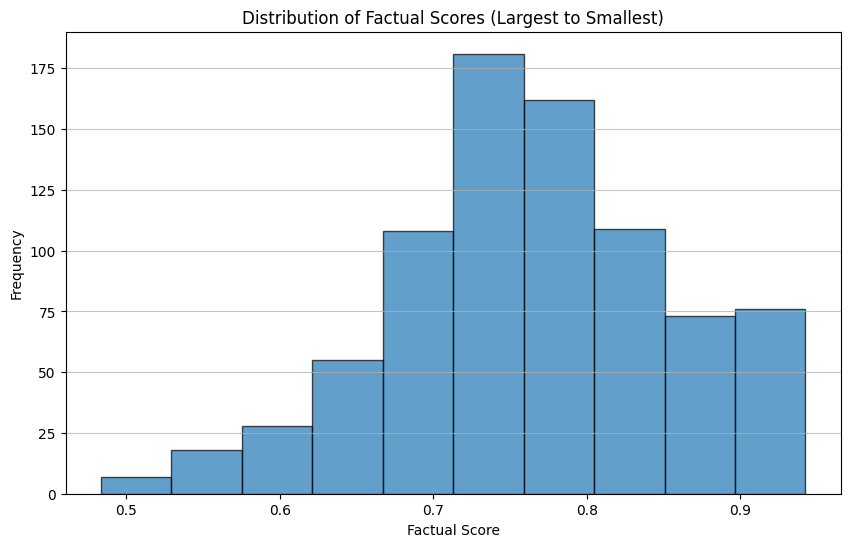

In [36]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(factual_scores.detach().cpu().numpy(), bins=10, edgecolor='black', alpha=0.7)
plt.title('Distribution of Factual Scores (Largest to Smallest)')
plt.xlabel('Factual Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Show the plot
plt.show()

In [239]:
aaa=factual_scores.detach().cpu().numpy()

In [304]:
from datasets import load_dataset

def load_mmlu_sampled_questions(subsets=None, num_samples=20, split="dev"):
    """
    从指定学科中抽取一定数量的样本（默认 20）
    - subsets: 学科名的列表
    - num_samples: 每个学科抽取的样本数
    - split: 'test', 'dev', 或 'validation' （MMLU 支持这三个划分）
    返回：包含所有学科问题的列表
    """
    all_questions = []
    
    # 遍历学科并抽取样本
    for subject in subsets:
        # 加载指定学科数据集
        ds = load_dataset("cais/mmlu", subject, split=split)
        print(subject)
        # 从每个学科中抽取 `num_samples` 个样本
        sampled_ds = ds.select(range(min(num_samples, len(ds))))
        
        # 将抽取的问题添加到所有问题列表中
        all_questions.extend(sampled_ds["question"])

    return all_questions

if __name__ == "__main__":
    # 示例学科
    subjects = ['abstract_algebra', 'all', 'anatomy', 'astronomy', 
                'business_ethics', 'clinical_knowledge', 'college_biology', 'college_chemistry', 
                'college_computer_science']
    
    # 抽取并合并 20 个问题
    questions = load_mmlu_sampled_questions(subjects, num_samples=20, split="dev")
    
    # 输出合并后的问题列表
    print(f"总共抽取了 {len(questions)} 个问题")
    print(questions[:5])  # 输出前 5 个问题作为示例


abstract_algebra
all
anatomy
astronomy
business_ethics
clinical_knowledge
college_biology
college_chemistry
college_computer_science
总共抽取了 60 个问题
['Find all c in Z_3 such that Z_3[x]/(x^2 + c) is a field.', 'Statement 1 | If aH is an element of a factor group, then |aH| divides |a|. Statement 2 | If H and K are subgroups of G then HK is a subgroup of G.', 'Statement 1 | Every element of a group generates a cyclic subgroup of the group. Statement 2 | The symmetric group S_10 has 10 elements.', 'Statement 1| Every function from a finite set onto itself must be one to one. Statement 2 | Every subgroup of an abelian group is abelian.', 'Find the characteristic of the ring 2Z.']


In [305]:
test_questions=[get_prompt_embedding_formatted(prompt,tokenizer,model) for prompt in questions]
test_questions=torch.stack(test_questions)
test_scores=[get_qa_score(prompt.to(torch.float32), VK) for prompt in test_questions]
test_scores=torch.stack(test_scores)

In [306]:
count = (test_scores >= 0.5).sum().item()
count/test_scores.shape[0]*100

23.333333333333332

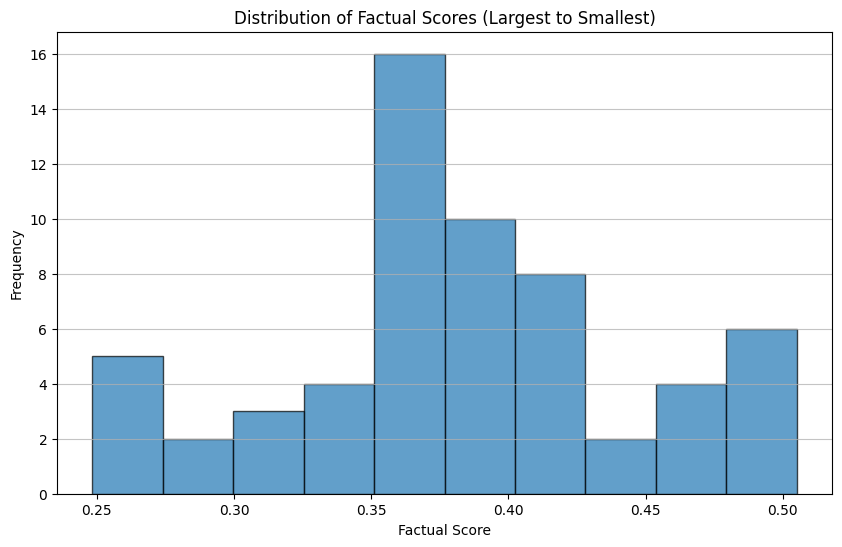

In [ ]:

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(test_scores.detach().cpu().numpy(), bins=10, edgecolor='black', alpha=0.7)
plt.title('Distribution of Factual Scores (Largest to Smallest)')
plt.xlabel('Factual Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Show the plot
plt.show()

In [307]:
train_data = load_dataset("gsm8k", "main", split="train")
test_data = load_dataset("gsm8k", "main", split="test")

In [308]:
# 抽取前1000个问题
sampled_data = train_data[:1000]

# 获取问题列表
questions = sampled_data["question"]

In [309]:
test_questions=[get_prompt_embedding_formatted(prompt,tokenizer,model) for prompt in questions]
test_questions=torch.stack(test_questions)
test_scores=[get_qa_score(prompt.to(torch.float32), VK) for prompt in test_questions]
test_scores=torch.stack(test_scores)

In [310]:
count = (test_scores >= 0.5).sum().item()
count/test_scores.shape[0]*100

1.5

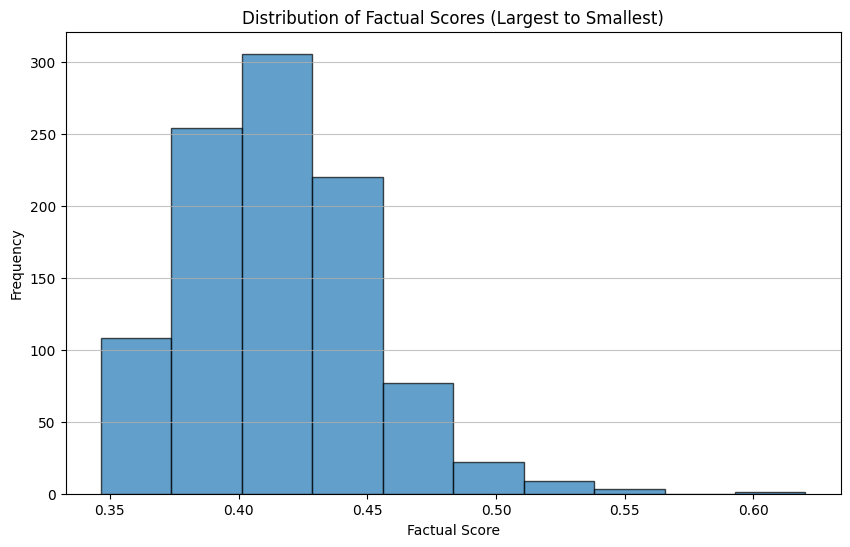

In [311]:

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(test_scores.detach().cpu().numpy(), bins=10, edgecolor='black', alpha=0.7)
plt.title('Distribution of Factual Scores (Largest to Smallest)')
plt.xlabel('Factual Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Show the plot
plt.show()